# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The "Who" includes the cybersecurity professionals who are tasked with securing an organization's IT information systems as well as the organizations leaders who make business decisons.

The "What" is that the cybersecurity professionals need to secure the IT systems and warn of any behaviors related to unusual cyber behaviors.

The "How" is learning about various cyber (whether malware or misinformation) behaviors. 

# 3. Homework - work with your own data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

import matplotlib.pyplot as plt

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

## Dataset 1: Ransomware

In [21]:
# Setup the Ransomware dataset

# Ransomware
r1_df = pd.read_csv('ransomware_wannalocker_08212017_1.csv')
r2_df = pd.read_csv('ransomware_wannalocker_08212017_2.csv')
r3_df = pd.read_csv('ransomware_wannalocker_08212017_3.csv')

ransomware_df = pd.concat([r1_df, r2_df, r3_df], ignore_index=True)

In [7]:
# Show the first few rows of the dataset
ransomware_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,157.240.2.36-10.42.0.151-443-45492-6,157.240.2.36,443,10.42.0.151,45492,6,21/08/2017 03:17:33,38,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RANSOMWARE_WANNALOCKER
1,157.240.2.36-10.42.0.151-443-45492-6,10.42.0.151,45492,157.240.2.36,443,6,21/08/2017 03:17:33,678,3,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RANSOMWARE_WANNALOCKER
2,10.42.0.151-31.13.80.5-56334-443-6,10.42.0.151,56334,31.13.80.5,443,6,21/08/2017 03:17:57,226491,6,7,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RANSOMWARE_WANNALOCKER
3,172.217.17.131-10.42.0.151-443-41602-6,10.42.0.151,41602,172.217.17.131,443,6,21/08/2017 03:17:45,26421468,4,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RANSOMWARE_WANNALOCKER
4,172.217.10.74-10.42.0.151-443-58679-6,10.42.0.151,58679,172.217.10.74,443,6,21/08/2017 03:18:17,37272,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,RANSOMWARE_WANNALOCKER


In [8]:
# Summarize the datasets using info()
ransomware_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10161 entries, 0 to 10160
Data columns (total 85 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flow ID                       10161 non-null  str    
 1    Source IP                    10161 non-null  str    
 2    Source Port                  10161 non-null  int64  
 3    Destination IP               10161 non-null  str    
 4    Destination Port             10161 non-null  int64  
 5    Protocol                     10161 non-null  int64  
 6    Timestamp                    10161 non-null  str    
 7    Flow Duration                10161 non-null  int64  
 8    Total Fwd Packets            10161 non-null  int64  
 9    Total Backward Packets       10161 non-null  int64  
 10  Total Length of Fwd Packets   10161 non-null  float64
 11   Total Length of Bwd Packets  10161 non-null  float64
 12   Fwd Packet Length Max        10161 non-null  float64
 13   Fwd Packet 

In [ ]:
# Summarize the datasets using describe()
ransomware_df.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,10161.000000,10161.000000,10161.000000,1.016100e+04,10161.000000,10161.000000,10161.000000,1.016100e+04,10161.000000,10161.000000,...,10161.000000,10161.000000,1.016100e+04,1.016100e+04,1.016100e+04,1.016100e+04,1.016100e+04,1.016100e+04,1.016100e+04,1.016100e+04
mean,38729.955221,5688.455861,8.370141,1.164242e+07,7.450743,8.173605,639.125283,7.608806e+03,240.447298,12.640980,...,1.560083,27.438047,1.620623e+05,2.259809e+04,1.858467e+05,1.449831e+05,4.837583e+06,3.072699e+05,5.112143e+06,4.603030e+06
std,18381.690409,15084.619085,4.598773,2.234266e+07,31.147723,70.426332,4259.927121,1.002535e+05,657.740777,54.361422,...,4.806549,6.785763,8.062992e+05,2.837245e+05,9.687750e+05,7.719402e+05,1.519591e+07,2.599193e+06,1.581407e+07,1.488543e+07
min,0.000000,0.000000,0.000000,5.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,34270.000000,80.000000,6.000000,3.785000e+04,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,43477.000000,443.000000,6.000000,5.182450e+05,2.000000,1.000000,32.000000,2.600000e+01,31.000000,0.000000,...,0.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,52303.000000,443.000000,6.000000,1.146270e+07,6.000000,4.000000,393.000000,4.040000e+02,242.000000,24.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65483.000000,65320.000000,17.000000,1.199865e+08,2147.000000,5768.000000,236739.000000,8.390542e+06,16416.000000,1460.000000,...,124.000000,44.000000,1.440777e+07,1.414633e+07,3.067630e+07,1.419512e+07,1.194360e+08,5.969266e+07,1.194360e+08,1.194360e+08


In [9]:
# Are there any duplicate rows?
print(f"Number of duplicate rows: {ransomware_df.duplicated().sum()}")
print(f"\nTotal rows: {len(ransomware_df)}")
print(f"Unique rows: {len(ransomware_df.drop_duplicates())}")

# Display duplicate rows
if ransomware_df.duplicated().sum() > 0:
    print("\nDuplicate rows:")
    print(ransomware_df[ransomware_df.duplicated(keep=False)].sort_values(by=list(ransomware_df.columns)).head(10))

Number of duplicate rows: 0

Total rows: 10161
Unique rows: 10161


In [10]:
# Are there any duplicate values in a given column (when this would be inappropriate?)
print("Duplicate values per column:\n")
for col in ransomware_df.columns:
    num_duplicates = ransomware_df[col].duplicated().sum()
    num_unique = ransomware_df[col].nunique()
    total = len(ransomware_df)
    print(f"{col}:")
    print(f"  Total values: {total}")
    print(f"  Unique values: {num_unique}")
    print(f"  Duplicate values: {num_duplicates}")
    print()

Duplicate values per column:

Flow ID:
  Total values: 10161
  Unique values: 5530
  Duplicate values: 4631

 Source IP:
  Total values: 10161
  Unique values: 333
  Duplicate values: 9828

 Source Port:
  Total values: 10161
  Unique values: 5112
  Duplicate values: 5049

 Destination IP:
  Total values: 10161
  Unique values: 641
  Duplicate values: 9520

 Destination Port:
  Total values: 10161
  Unique values: 1023
  Duplicate values: 9138

 Protocol:
  Total values: 10161
  Unique values: 3
  Duplicate values: 10158

 Timestamp:
  Total values: 10161
  Unique values: 2387
  Duplicate values: 7774

 Flow Duration:
  Total values: 10161
  Unique values: 9409
  Duplicate values: 752

 Total Fwd Packets:
  Total values: 10161
  Unique values: 165
  Duplicate values: 9996

 Total Backward Packets:
  Total values: 10161
  Unique values: 177
  Duplicate values: 9984

Total Length of Fwd Packets:
  Total values: 10161
  Unique values: 1441
  Duplicate values: 8720

 Total Length of Bwd Pa

In [11]:
# What are the mean, median, and mode of each column?
print("Mean, Median, and Mode for each column:\n")

for col in ransomware_df.columns:
    print(f"{col}:")
    
    # Mean and Median (for numeric columns only)
    if ransomware_df[col].dtype in ['int64', 'float64']:
        print(f"  Mean: {ransomware_df[col].mean()}")
        print(f"  Median: {ransomware_df[col].median()}")
    else:
        print(f"  Mean: N/A (non-numeric)")
        print(f"  Median: N/A (non-numeric)")
    
    # Mode (for all columns)
    mode_vals = ransomware_df[col].mode()
    if len(mode_vals) > 0:
        print(f"  Mode: {mode_vals.values}")
    else:
        print(f"  Mode: No mode found")
    print()

Mean, Median, and Mode for each column:

Flow ID:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['8.0.6.4-8.6.0.1-0-0-0']
Length: 1, dtype: str

 Source IP:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['10.42.0.151']
Length: 1, dtype: str

 Source Port:
  Mean: 38729.95522094282
  Median: 43477.0
  Mode: [443]

 Destination IP:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['10.42.0.1']
Length: 1, dtype: str

 Destination Port:
  Mean: 5688.455860643638
  Median: 443.0
  Mode: [443]

 Protocol:
  Mean: 8.370140734179706
  Median: 6.0
  Mode: [6]

 Timestamp:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['21/08/2017 11:18:11', '21/08/2017 11:30:36']
Length: 2, dtype: str

 Flow Duration:
  Mean: 11642424.870288357
  Median: 518245.0
  Mode: [38]

 Total Fwd Packets:
  Mean: 7.450743037102647
  Median: 2.0
  Mode: [1]

 Total Backward Packets:
  Mean: 8.1736049601417

In [ ]:
# Are there any missing or null values? Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?
print("Missing or Null Values:\n")

missing_count = ransomware_df.isnull().sum()
missing_percent = (ransomware_df.isnull().sum() / len(ransomware_df)) * 100

missing_df = pd.DataFrame({
    'Column': ransomware_df.columns,
    'Missing Count': missing_count.values,
    'Missing Percent': missing_percent.values
})

print(missing_df.to_string(index=False))
print(f"\nTotal rows with at least one missing value: {ransomware_df.isnull().any(axis=1).sum()}")

# Show a few rows with missing values if they exist
if ransomware_df.isnull().any().any():
    print("\nSample rows with missing values:")
    print(ransomware_df[ransomware_df.isnull().any(axis=1)].head())

Missing or Null Values:

                      Column  Missing Count  Missing Percent
                     Flow ID              0              0.0
                   Source IP              0              0.0
                 Source Port              0              0.0
              Destination IP              0              0.0
            Destination Port              0              0.0
                    Protocol              0              0.0
                   Timestamp              0              0.0
               Flow Duration              0              0.0
           Total Fwd Packets              0              0.0
      Total Backward Packets              0              0.0
 Total Length of Fwd Packets              0              0.0
 Total Length of Bwd Packets              0              0.0
       Fwd Packet Length Max              0              0.0
       Fwd Packet Length Min              0              0.0
      Fwd Packet Length Mean              0              0.0

In [ ]:
# Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

# There is really no way to know what the "correct" data should look like, but we can look for some common inconsistencies. For example, if there are any date columns, we can check if any dates are in the future or if any actions occur before a certain date (e.g. before 2017 when WannaLocker was active).

In [10]:
# Encode any categorical variables (e.g. with one-hot encoding.)

## Dataset 2: Misinformation

In [ ]:
# Setup the Misinformation dataset
m1_df = pd.read_csv('misinformation.csv', encoding='latin1',  dtype=str)

m1_df = m1_df.loc[:, ~m1_df.columns.str.contains('^Unnamed')]
misinformation_df = m1_df

# misinformation_df['label'] = misinformation_df['label'].astype(int)

ValueError: cannot convert float NaN to integer

In [12]:
# Show the first few rows of the dataset
misinformation_df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [13]:
# Summarize the datasets using info()
misinformation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78097 entries, 0 to 78096
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   75136 non-null  str  
 1   text    74488 non-null  str  
 2   label   73776 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


In [15]:
# Summarize the datasets using describe()
misinformation_df.describe()

,title,text,label
count,75136,74488,73776
unique,65108,64574,1363
top,1,,1
freq,20,739,37038


In [16]:
# Are there any duplicate rows?
print(f"Number of duplicate rows: {misinformation_df.duplicated().sum()}")
print(f"\nTotal rows: {len(misinformation_df)}")
print(f"Unique rows: {len(misinformation_df.drop_duplicates())}")

# Display duplicate rows
if misinformation_df.duplicated().sum() > 0:
    print("\nDuplicate rows:")
    print(misinformation_df[misinformation_df.duplicated(keep=False)].sort_values(by=list(misinformation_df.columns)).head(10))

Number of duplicate rows: 11622

Total rows: 78097
Unique rows: 66475

Duplicate rows:
      title text label
449          NaN   NaN
673          NaN   NaN
33641        NaN   NaN
33784        NaN   NaN
40801        NaN   NaN
40944        NaN   NaN
49468        NaN   NaN
62192        NaN   NaN
69132        NaN   NaN
69136        NaN   NaN


In [17]:
# Are there any duplicate values in a given column (when this would be inappropriate?)
print("Duplicate values per column:\n")
for col in misinformation_df.columns:
    num_duplicates = misinformation_df[col].duplicated().sum()
    num_unique = misinformation_df[col].nunique()
    total = len(misinformation_df)
    print(f"{col}:")
    print(f"  Total values: {total}")
    print(f"  Unique values: {num_unique}")
    print(f"  Duplicate values: {num_duplicates}")
    print()

Duplicate values per column:

title:
  Total values: 78097
  Unique values: 65108
  Duplicate values: 12988

text:
  Total values: 78097
  Unique values: 64574
  Duplicate values: 13522

label:
  Total values: 78097
  Unique values: 1363
  Duplicate values: 76733



In [18]:
# What are the mean, median, and mode of each column?
print("Mean, Median, and Mode for each column:\n")

for col in misinformation_df.columns:
    print(f"{col}:")
    
    # Mean and Median (for numeric columns only)
    if misinformation_df[col].dtype in ['int64', 'float64']:
        print(f"  Mean: {misinformation_df[col].mean()}")
        print(f"  Median: {misinformation_df[col].median()}")
    else:
        print(f"  Mean: N/A (non-numeric)")
        print(f"  Median: N/A (non-numeric)")
    
    # Mode (for all columns)
    mode_vals = misinformation_df[col].mode()
    if len(mode_vals) > 0:
        print(f"  Mode: {mode_vals.values}")
    else:
        print(f"  Mode: No mode found")
    print()

Mean, Median, and Mode for each column:

title:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['1']
Length: 1, dtype: str

text:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
[' ']
Length: 1, dtype: str

label:
  Mean: N/A (non-numeric)
  Median: N/A (non-numeric)
  Mode: <StringArray>
['1']
Length: 1, dtype: str



In [19]:
# Are there any missing or null values? Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?
print("Missing or Null Values:\n")

missing_count = misinformation_df.isnull().sum()
missing_percent = (misinformation_df.isnull().sum() / len(misinformation_df)) * 100

missing_df = pd.DataFrame({
    'Column': misinformation_df.columns,
    'Missing Count': missing_count.values,
    'Missing Percent': missing_percent.values
})

print(missing_df.to_string(index=False))
print(f"\nTotal rows with at least one missing value: {misinformation_df.isnull().any(axis=1).sum()}")

# Show a few rows with missing values if they exist
if misinformation_df.isnull().any().any():
    print("\nSample rows with missing values:")
    print(misinformation_df[misinformation_df.isnull().any(axis=1)].head())

Missing or Null Values:

Column  Missing Count  Missing Percent
 title           2961         3.791439
  text           3609         4.621176
 label           4321         5.532863

Total rows with at least one missing value: 4920

Sample rows with missing values:
                                            title  \
1                                             NaN   
43                                            NaN   
162                                           NaN   
185                                           NaN   
188  Jack Heart: LUCIFER in the Temple of the Dog   

                                                  text label  
1       Did they post their votes for Hillary already?     1  
43   True. Hillary needs a distraction and what bet...     1  
162  All eyes on Electoral delegates. The People kn...     1  
185                                               Cool     1  
188  LUCIFER in the Temple of the Dog I By Jack Hea...   NaN  


In [ ]:
# Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

# There is really no way to know what the "correct" data should look like as the goal of the dataset is to find inconsistencies in text. This helps in the indentification of misinformation.

In [ ]:
# Encode any categorical variables (e.g. with one-hot encoding.)

# Since all columns are text fields

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

Text(0.5, 1, 'POST: How do you feel \n about doing science?')

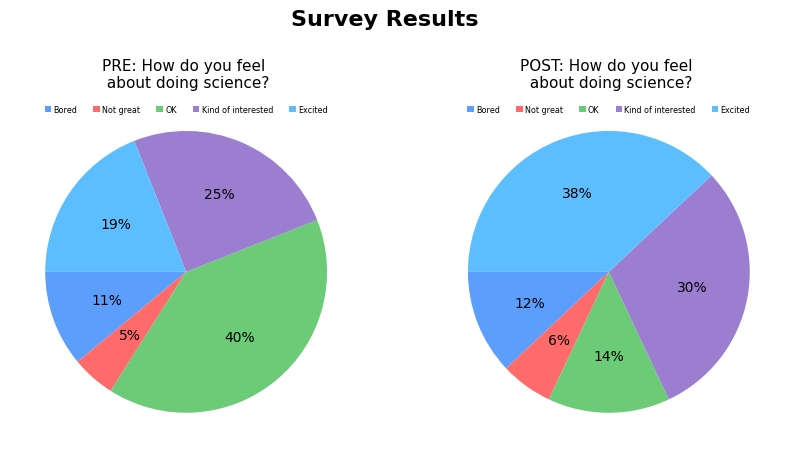

In [11]:

# Double Pie Chart (Figure 0.4 on pg. 5)

# Data
labels = ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited']
data1 = [11, 5, 40, 25, 19]
data2 = [12, 6, 14, 30, 38]

# Custom Color Palette
# You can use standard names, Hex codes, or RGB tuples
colors_chart = [ '#5B9EFC', '#FF6B6B', '#6BCB77', '#9C7ED1', "#5DBEFF"]  # Soft Coral, Blue, Green

# Create subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Add Master Title
fig.suptitle('Survey Results', fontsize=16, fontweight='bold', y=1.02)

# Chart 1
wedges1, _, _ = ax1.pie(data1, autopct='%1.0f%%', startangle=180, colors=colors_chart)
ax1.legend(
    wedges1, labels, title="", 
    loc="lower center", bbox_to_anchor=(0.5, 0.93), ncol=5,
    frameon=False, fontsize='xx-small', title_fontsize='x-small',
    handlelength=0.8, handleheight=0.8, handletextpad=0.3, borderpad=0.3
)
# Center the title above the centered legend
ax1.set_title('PRE: How do you feel \n about doing science?', y=1, loc='center', fontsize=11)

# Chart 2
wedges2, _, _ = ax2.pie(data2, autopct='%1.0f%%', startangle=180, colors=colors_chart)
ax2.legend(
    wedges2, labels, title="", 
    loc="lower center", bbox_to_anchor=(0.5, 0.93), ncol=5,
    frameon=False, fontsize='xx-small', title_fontsize='x-small',
    handlelength=0.8, handleheight=0.8, handletextpad=0.3, borderpad=0.3
)
# Center the title above the centered legend
ax2.set_title('POST: How do you feel \n about doing science?', y=1, loc='center', fontsize=11)